In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [4]:
def preprocess(images, labels):
    images = tf.image.resize(images, (96, 96))
    images = tf.cast(images, tf.float32)
    return images, labels

In [5]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).shuffle(10000).batch(64).map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
).batch(64).map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(64).map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [6]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10


c:\Users\PC-LAB1\Desktop\shok\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


704/704 ━━━━━━━━━━━━━━━━━━━━ 191s 267ms/step - accuracy: 0.3278 - loss: 1.8604 - val_accuracy: 0.4476 - val_loss: 1.5775
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 158s 204ms/step - accuracy: 0.3945 - loss: 1.6824 - val_accuracy: 0.4630 - val_loss: 1.5220
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 185s 180ms/step - accuracy: 0.4108 - loss: 1.6367 - val_accuracy: 0.4822 - val_loss: 1.4885
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 181ms/step - accuracy: 0.4234 - loss: 1.6051 - val_accuracy: 0.4868 - val_loss: 1.4559
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 128s 182ms/step - accuracy: 0.4368 - loss: 1.5789 - val_accuracy: 0.4914 - val_loss: 1.4444
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 129s 183ms/step - accuracy: 0.4411 - loss: 1.5666 - val_accuracy: 0.4970 - val_loss: 1.4353
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 184ms/step - accuracy: 0.4464 - loss: 1.5519 - val_accuracy: 0.4944 - val_loss: 1.4297
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 130s 185ms/step - accuracy: 0.4501 - loss: 1.54

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

test_loss, test_accuracy = model.evaluate(test_ds)

print("Test accuracy:", test_accuracy)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 203s 278ms/step - accuracy: 0.2508 - loss: 3.4653 - val_accuracy: 0.3564 - val_loss: 1.7985
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 166s 235ms/step - accuracy: 0.3385 - loss: 1.8415 - val_accuracy: 0.3884 - val_loss: 1.7076
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 168s 238ms/step - accuracy: 0.3806 - loss: 1.7188 - val_accuracy: 0.4382 - val_loss: 1.5628
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 174s 247ms/step - accuracy: 0.4135 - loss: 1.6345 - val_accuracy: 0.4746 - val_loss: 1.4935
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 161s 228ms/step - accuracy: 0.4378 - loss: 1.5618 - val_accuracy: 0.4886 - val_loss: 1.4451
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 158s 225ms/step - accuracy: 0.4588 - loss: 1.5037 - val_accuracy: 0.4982 - val_loss: 1.4062
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 176s 250ms/step - accuracy: 0.4757 - loss: 1.4503 - val_accuracy: 0.5104 - val_loss: 1.3818
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 164s 233ms/step - accuracy: 0.4924 -

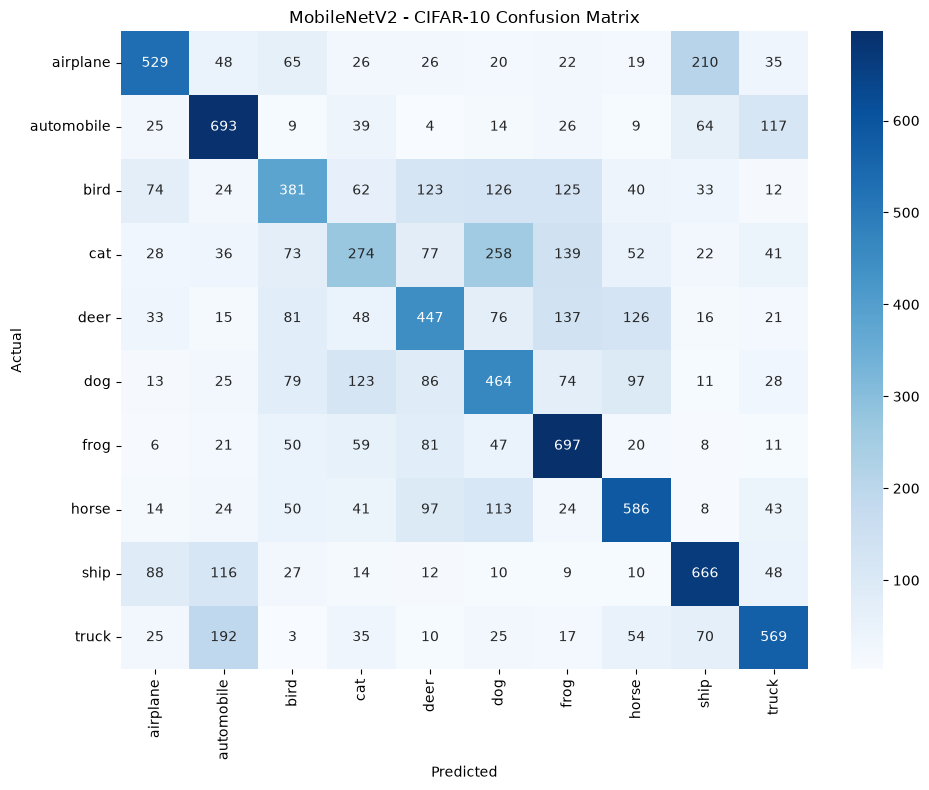

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

y_true = []
y_pred = []

# Process test images in batches
for i in range(0, len(X_test), 32):

    images = X_test[i:i+32]
    labels = y_test[i:i+32]

    # Resize only this batch
    images = tf.image.resize(images, (96, 96))

    # Predict
    predictions = model.predict(images, verbose=0)

    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.flatten())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 - CIFAR-10 Confusion Matrix")

plt.tight_layout()
plt.show()